# stacked 오토인코더

In [1]:
import sys
import sklearn
import tensorflow as tf
import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt

In [4]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255

X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

In [6]:
tf.random.set_seed(42)
np.random.seed(42)

stacked_encoder = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(100, activation="selu"),
    tf.keras.layers.Dense(30, activation="selu")
])

stacked_decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="selu", input_shape=[30]),
    tf.keras.layers.Dense(28 * 28, activation="sigmoid"),
    tf.keras.layers.Reshape([28, 28])
])

stacked_ae = tf.keras.Sequential([stacked_encoder, stacked_decoder])

In [7]:
def rounded_accuracy(y_true, y_pred):
    return tf.keras.metrics.binary_accuracy(tf.round(y_true), tf.round(y_pred))

In [8]:
stacked_ae.compile(loss="binary_crossentropy",
                   optimizer=tf.keras.optimizers.SGD(lr=1.5),
                   metrics=[rounded_accuracy])
history = stacked_ae.fit(X_train, X_train, epochs=20, validation_data=(X_valid, X_valid))

Epoch 1/20



1719/1719 [==============================] - 4s 2ms/step - loss: 0.6580 - rounded_accuracy: 0.6015 - val_loss: 0.5925 - val_rounded_accuracy: 0.6908
Epoch 2/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.5347 - rounded_accuracy: 0.7242 - val_loss: 0.5074 - val_rounded_accuracy: 0.7366
Epoch 3/20
1719/1719 [==============================] - 3s 1ms/step - loss: 0.4973 - rounded_accuracy: 0.7432 - val_loss: 0.4939 - val_rounded_accuracy: 0.7468
Epoch 4/20
1719/1719 [==============================] - 3s 2ms/step - loss: 0.4856 - rounded_accuracy: 0.7560 - val_loss: 0.4816 - val_rounded_accuracy: 0.7621
Epoch 5/20
1719/1719 [==============================] - 2s 1ms/step - loss: 0.4703 - rounded_accuracy: 0.7735 - val_loss: 0.4631 - val_rounded_accuracy: 0.7801
Epoch 6/20
1719/1719 [==============================] - 3s 1ms/step - loss: 0.4495 - rounded_accuracy: 0.7905 - val_loss: 0.4411 - val_rounded_accuracy: 0.7952
Epoch 7/20
1719/1719 [=============================

In [9]:
def show_reconstructions(model, images=X_valid, n_images=10):
    reconstructions = model.predict(images[:n_images])
    plt.figure(figsize=(n_images * 1.5, 3))
    for index in range(n_images):
        plt.subplot(2, n_images, index + 1)
        plt.imshow(images[index])
        plt.subplot(2, n_images, n_images + index + 1)
        plt.imshow(reconstructions[index])


1/1 [==============================] - 0s 19ms/step


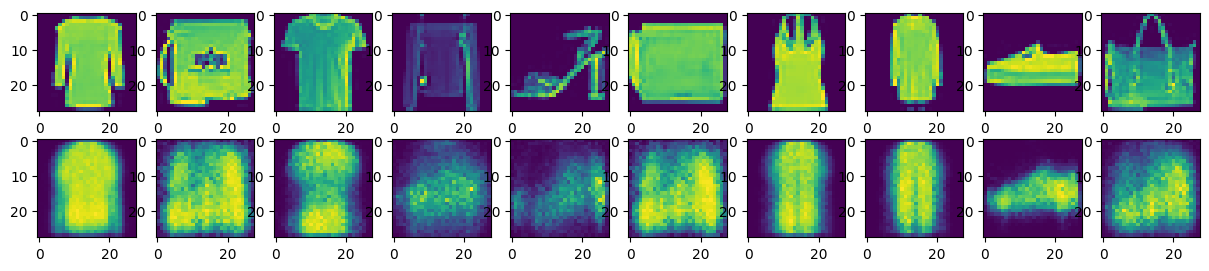

In [ ]:
show_reconstructions(stacked_ae)


In [ ]:
save_fig("reconstructions_plot")

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

In [13]:
(X_train, _), (X_test, _) = fashion_mnist.load_data()


In [14]:
x_train = X_train.astype('float32') / 255
x_test = X_test.astype('float32') / 255

x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(x_train.shape)

(60000, 28, 28, 1)


In [15]:
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

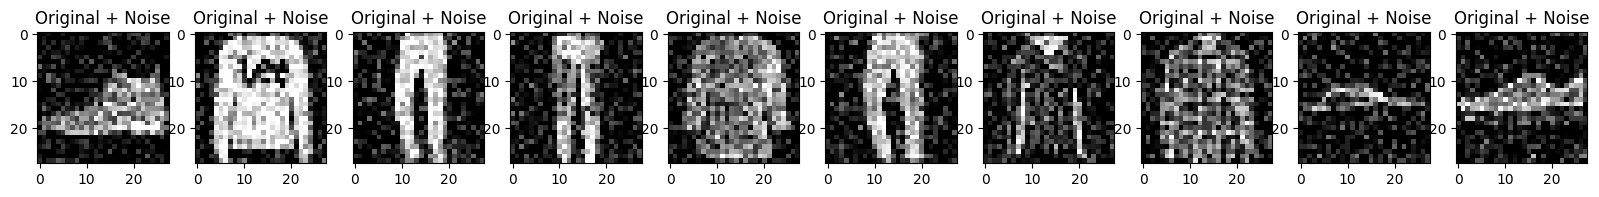

In [16]:
n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.title("Original + Noise")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
plt.show()

In [23]:
class Denoise(Model):
    def __init__(self):
        super(Denoise, self).__init__()
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Conv2D(16, (3, 3), activation='relu', padding='same', strides=2),
            layers.Conv2D(8, (3, 3), activation='relu', padding='same', strides=2),
        ])
        self.decoder = tf.keras.Sequential([
            layers.Conv2DTranspose(8, kernel_size=3, strides=2, activation='relu', padding='same'),
            layers.Conv2DTranspose(16, kernel_size=3, strides=2, activation='relu', padding='same'),
            layers.Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same')
        ])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [24]:
autoencoder = Denoise()

In [25]:
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

In [26]:
autoencoder.fit(x_train_noisy, x_train, epochs=10, validation_data=(x_test_noisy, x_test))

Epoch 1/10
1875/1875 [==============================] - 9s 4ms/step - loss: 0.0168 - val_loss: 0.0101
Epoch 2/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0093 - val_loss: 0.0088
Epoch 3/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0084 - val_loss: 0.0081
Epoch 4/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0078 - val_loss: 0.0077
Epoch 5/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0076 - val_loss: 0.0075
Epoch 6/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0074 - val_loss: 0.0074
Epoch 7/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 8/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0072 - val_loss: 0.0072
Epoch 9/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0071 - val_loss: 0.0071
Epoch 10/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.007

In [27]:
autoencoder.encoder.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 14, 14, 16)        160       
                                                                 
 conv2d_3 (Conv2D)           (None, 7, 7, 8)           1160      
                                                                 
Total params: 1320 (5.16 KB)
Trainable params: 1320 (5.16 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [28]:
autoencoder.decoder.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_transpose (Conv2DTr  (None, 14, 14, 8)         584       
 anspose)                                                        
                                                                 
 conv2d_transpose_1 (Conv2D  (None, 28, 28, 16)        1168      
 Transpose)                                                      
                                                                 
 conv2d_4 (Conv2D)           (None, 28, 28, 1)         145       
                                                                 
Total params: 1897 (7.41 KB)
Trainable params: 1897 (7.41 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [29]:
encoded_imgs = autoencoder.encoder(x_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

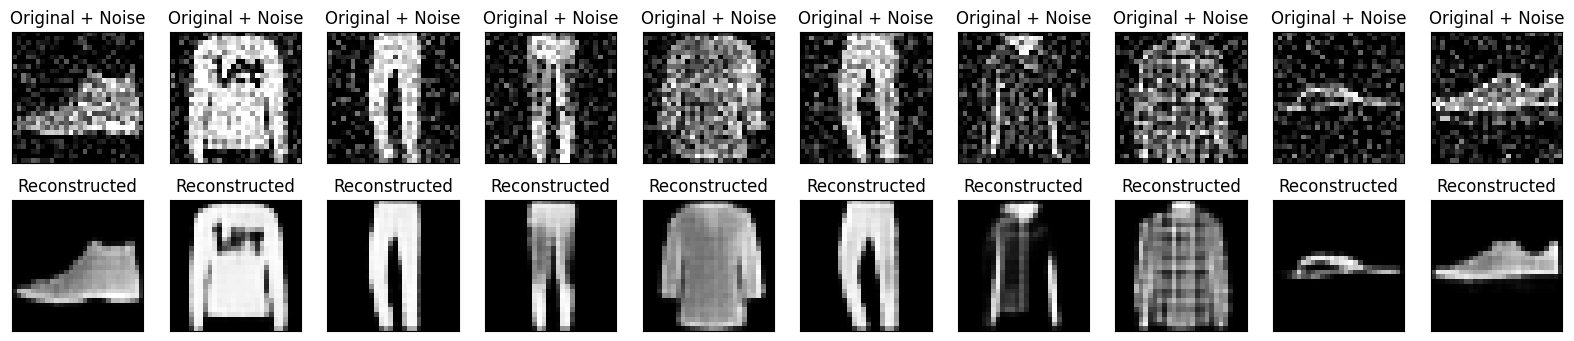

In [32]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.title("Original + Noise")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.title("Original")
    plt.imshow(tf.squeeze(x_test[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + 1 + n)
    plt.title("Reconstructed")
    plt.imshow(tf.squeeze(decoded_imgs[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()